## Clone repository

In [1]:
# # Clone the repository containing the project code
import sys
import os
repo_dir = 'cell-fuzzy-seg'
if not os.path.exists(repo_dir):
    !git clone --branch homolog https://github.com/Pedro-io/cell-fuzzy-seg.git
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

Cloning into 'cell-fuzzy-seg'...
remote: Enumerating objects: 293, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 293 (delta 30), reused 79 (delta 19), pack-reused 201 (from 2)
Receiving objects: 100% (293/293), 212.69 MiB | 28.78 MiB/s, done.
Resolving deltas: 100% (101/101), done.
Updating files: 100% (183/183), done.
/content/cell-fuzzy-seg


### Install Dependecies


In [2]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 100.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 84.0 MB/s eta 0:00:00:00:0100:01


Check GPU and instantiate model - will download weights.

In [3]:
import numpy as np
from cellpose import models, core, io, plot, transforms
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt
from natsort import natsorted
import cv2
from skimage import segmentation
from PIL import Image
import xml.etree.ElementTree as ET

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
if core.use_gpu()==False:
  raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=True)

creating new log file
2026-05-03 21:55:20,479 [INFO] WRITING LOG OUTPUT TO /root/.cellpose/run.log
2026-05-03 21:55:20,480 [INFO] 
cellpose version: 	4.1.1 
platform:       	linux 
python version: 	3.12.13 
torch version:  	2.10.0+cu128
2026-05-03 21:55:20,895 [INFO] ** TORCH CUDA version installed and working. **
2026-05-03 21:55:20,896 [INFO] ** TORCH CUDA version installed and working. **
2026-05-03 21:55:20,897 [INFO] >>>> using GPU (CUDA)
2026-05-03 21:55:23,298 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to /root/.cellpose/models/cpsam



100%|██████████| 1.15G/1.15G [00:04<00:00, 262MB/s]


Input directory with your images:

In [4]:
from src.data.load.monuseg_dataset import MonusegDataset

data = MonusegDataset(
  dataset_name="monuseg",
  config_key="monuseg_training"
  )

2026-05-03 21:55:31.695 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:104 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations


In [5]:
len(data)

30

## Run Cellpose-SAM on one image in folder

Here are some of the parameters you can change:

* ***flow_threshold*** is  the  maximum  allowed  error  of  the  flows  for  each  mask.   The  default  is 0.4.
    *  **Increase** this threshold if cellpose is not returning as many masks as you’d expect (or turn off completely with 0.0)
    *   **Decrease** this threshold if cellpose is returning too many ill-shaped masks.

* ***cellprob_threshold*** determines proability that a detected object is a cell.   The  default  is 0.0.
    *   **Decrease** this threshold if cellpose is not returning as many masks as you’d expect or if masks are too small
    *   **Increase** this threshold if cellpose is returning too many masks esp from dull/dim areas.

* ***tile_norm_blocksize*** determines the size of blocks used for normalizing the image. The default is 0, which means the entire image is normalized together.
  You may want to change this to 100-200 pixels if you have very inhomogeneous brightness across your image.



In [6]:
img = data[0]['image']

print(f'your image has shape: {img.shape}. Assuming channel dimension is last with {img.shape[-1]} channels')

2026-05-03 21:55:46.711 | DEBUG    | src.data.load.monuseg_dataset:_load_image:60 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-05-03 21:55:46.756 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:82 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml
2026-05-03 21:55:46.757 | DEBUG    | src.data.load.monuseg_dataset:_load_image:60 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif


your image has shape: (1000, 1000, 3). Assuming channel dimension is last with 3 channels


### Channel Selection:

- Use the dropdowns below to select the _zero-indexed_ channels of your image to segment. The order does not matter. Remember to rerun the cell after you edit the dropdowns.

- If you have a histological image taken in brightfield, you don't need to adjust the channels.

- If you have a fluroescent image with multiple stains, you should choose one channel with a cytoplasm/membrane stain, one channel with a nuclear stain, and set the third channel to `None`. Choosing multiple channels may produce segmentaiton of all the structures in the image. If you have retrained the model on your data with a thrid stain (described below), you can run segmentation with all channels.

In [8]:
first_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
second_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]
third_channel = '0' # @param ['None', 0, 1, 2, 3, 4, 5]

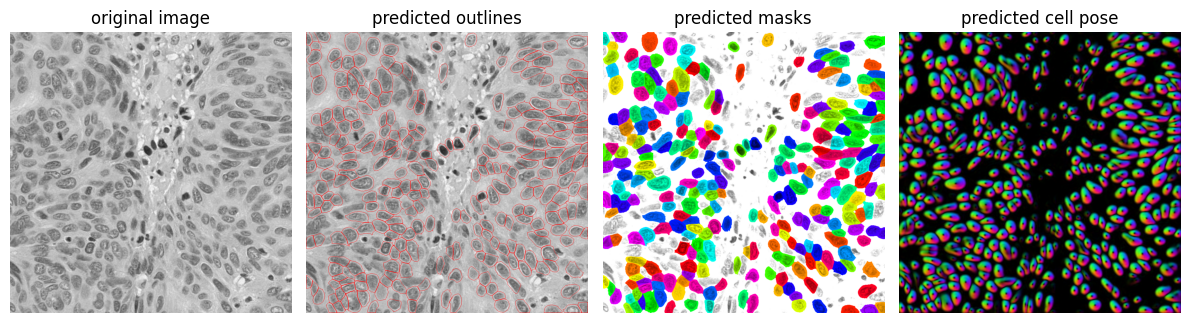

In [9]:
selected_channels = []
for i, c in enumerate([first_channel, second_channel, third_channel]):
  if c == 'None':
    continue
  if int(c) > img.shape[-1]:
    assert False, 'invalid channel index, must have index greater or equal to the number of channels'
  if c != 'None':
    selected_channels.append(int(c))



img_selected_channels = np.zeros_like(img)
img_selected_channels[:, :, :len(selected_channels)] = img[:, :, selected_channels]


flow_threshold = 0.4
cellprob_threshold = -4.0
tile_norm_blocksize = 0

transforms.normalize_img(img, normalize=True, norm3D=True, invert=True, lowhigh=None, percentile=(1.0, 99.0), sharpen_radius=0, smooth_radius=0, tile_norm_blocksize=0, tile_norm_smooth3D=1, axis=-1)

masks, flows, styles = model.eval(img_selected_channels, batch_size=10, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize}, diameter=100)

fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, img_selected_channels, masks, flows[0])
plt.tight_layout()
plt.show()


## Run Cellpose-SAM on folder of images

if you have small images, you may want to load all of them first and then run, so that they can be batched together on the GPU

In [13]:
# Import output writer utility
from src.io.output_writer import OutputWriter

In [14]:
output_dir = "/content/cell-fuzzy-seg/data/outputs"
saver = OutputWriter(output_dir)

In [11]:
print("loading images")
imgs = [data[i]['image'] for i in trange(len(data))]

print("running cellpose-SAM")
masks, flows, styles = model.eval(imgs, batch_size=10, flow_threshold=flow_threshold, cellprob_threshold=cellprob_threshold,
                                  normalize={"tile_norm_blocksize": tile_norm_blocksize})
# tentar diminuir o threshold para ver se consegue pegar mais células, mas cuidado para não pegar muito ruído

loading images


100%|██████████| 30/30 [00:13<00:00,  2.29it/s]

running cellpose-SAM
2026-05-03 20:55:51,469 [INFO] 0%|          | 0/30 [00:00<?, ?it/s]


2026-05-03 21:00:53,141 [INFO] 100%|##########| 30/30 [05:01<00:00, 10.06s/it]


In [15]:
print("saving masks")
for i in trange(len(data)):
    f = data[i]['id']
    saver.save_segmentation(f, masks[i])
    
    


saving masks


100%|██████████| 30/30 [00:13<00:00,  2.25it/s]
